## Motivation
We hope you have fun doing this task as well as learn something new.

Do not be discouraged if you find the task challenging. Feel free to research as much as you want on Google or any other resource to solve this task. You are welcome to copy code snippets from stackoverflow, tutorials, blog posts, etc to help you finish the task. Make sure you understand them though :)

The goal is to push yourself a little and see how you like solving new problems using scientific computing and data analysis.

**About colab**

Please create a duplicate of this notebook using File > Save a Copy in Drive. Share your solution via a link to your local copy of the notebook.

You can solve the entirety of this task using a free kernel running in the cloud. Just click 'Connect' on the top right of the notebook. You can use any python libraries you want *unless* explicitly told to code your own algorithm. If a library you want to use is not already available from the colab runtime, go to 'Help' > 'Search code snippets' > Type 'Importing a library that is not in Colab' to learn how to install a library using pip.


# Part 1
Understanding Stochastic Gradient Descent.
In this exercise, we want to implement [Stochastic Gradient descent](https://en.wikipedia.org/wiki/Stochastic_gradient_descent) without using a built-in optimizer, to understand how parameters are optimized at the low level.

Let's consider a toy problem of [Logistic Regression](https://en.wikipedia.org/wiki/Logistic_regression). The data generation process is such that we have one floating point variable $x \in [0,1]$, and one categorical variable $y\in \{0,1\}$. The Logistic Regression problem is to find the optimal parameters for the logistic function to predict the probability of $y$ given $x$.

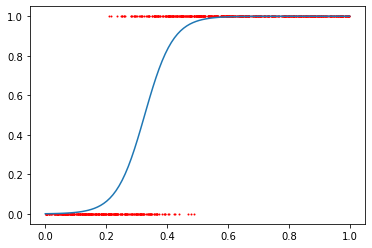

In the image above, the x and y axis correspond to the variables defined previously, with the red "dots" the true data as generated by the process defined below, and the blue line is the optimal logistic decision function learned from the data.

The optimal parameters can be found numerically using gradient descent. In this case, we will be using SGD (batched gradient descent) to optimize the two parameters in the logistic function, $\beta_1, \beta_2$.

If ${p(x)={\frac {1}{1+e^{-(\beta _{1}+\beta _{2}x)}}}}$, then we want to find $\beta_1, \beta_2$ such that the [negative log likelihood](https://en.wikipedia.org/wiki/Likelihood_function) is minimized. In this case, ${\ell =\sum _{k=1}^{K}\left(\,y_{k}\ln(p_{k})+(1-y_{k})\ln(1-p_{k})\right)}$, and the SGD formula is simply:
$\beta_i = \beta_{i-1} - \alpha * \nabla \ell$.

The data generation process as well as the pseudo-code is provided for you below, your task is to fill in the appropriate pytorch code. *Do not use the built-in optimizer*, implement SGD using tensor operations alone.


In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt

In [ ]:
def generate_data():
  data = torch.rand(1000, 2)
  label = ((data[:,0]+0.3*data[:,1]) > 0.5).to(torch.int)
  return data[:,0], label

Epoch 1, Loss: 328.6291
Epoch 2, Loss: 207.8462
Epoch 3, Loss: 191.3451
Epoch 4, Loss: 184.3514
Epoch 5, Loss: 180.6176
Epoch 6, Loss: 178.3835
Epoch 7, Loss: 176.9518
Epoch 8, Loss: 175.9917
Epoch 9, Loss: 175.3270
Epoch 10, Loss: 174.8560
Epoch 11, Loss: 174.5163
Epoch 12, Loss: 174.2682
Epoch 13, Loss: 174.0852
Epoch 14, Loss: 173.9494
Epoch 15, Loss: 173.8481


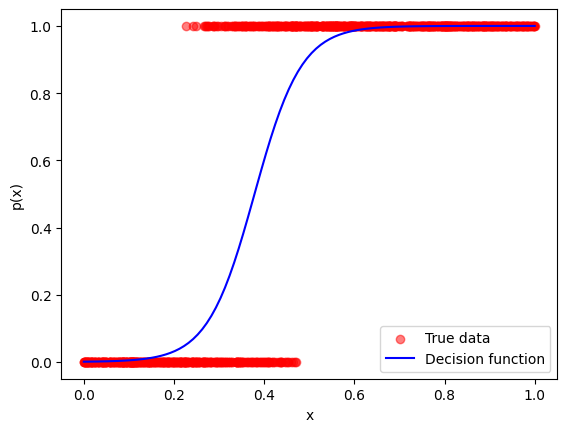

In [ ]:
input, label = generate_data()

inputs = torch.split(input, 32)
labels = torch.split(label, 32)

# Define the two variables to optimize
b1 = torch.autograd.Variable(torch.tensor([0.01]), requires_grad=True)
b2 = torch.autograd.Variable(torch.tensor([0.01]), requires_grad=True)

learning_rate = 0.3

for epoch in range(15):
  total_loss = 0
  for x, y in zip(inputs,labels):
    # Calculate p_x as per formula above
    p_x = 1 / (1 + torch.exp(-(b1 + b2 * x)))

    # calculate the negative loss likelihood
    loss = -torch.sum(y * torch.log(p_x) + (1 - y) * torch.log(1 - p_x))

    # calculate the gradient of the loss
    loss.backward()

    # Update the parameters b according to SGD formula
    with torch.no_grad():
        b1 += -learning_rate * b1.grad
        b2 += -learning_rate * b2.grad

        b1.grad.zero_()
        b2.grad.zero_()

    total_loss += loss.item()

  print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

# Visualization
x_vals = torch.linspace(0, 1, 100)
predicted_probs = 1 / (1 + torch.exp(-(b1 + b2 * x_vals)))

plt.scatter(input, label, color='red', alpha=0.5, label='True data')
plt.plot(x_vals, predicted_probs.detach().numpy(), color='blue', label='Decision function')
plt.xlabel('x')
plt.ylabel('p(x)')
plt.legend()
plt.show()

# Part 2-1

Researchers have measured a bivariate timeseries, but the equipment was unreliable so the data has gaps as well as noise. The data can be found in [data.csv](https://gist.github.com/tmramalho/51733432c88e2b834dbd70353849f887)

In this exercise, we want to train an [MLP](https://en.wikipedia.org/wiki/Multilayer_perceptron) to regress the full observed trajectory from the measured data. Formally, the MLP will be used to approximate the function $f:\mathbb{R} \rightarrow \mathbb{R}^2 ; f(t) = (x(t), y(t))$. In other words, the model takes the current time as an input, and predicts the values of `x` and `y` at that time based only on the measured data.

Your task is to define the data loader, the MLP model and the loss function to complete this task successfully. For this problem you will need to use a regression loss, not a classification loss.

Successful training should result in a data interpolation similar to the below:
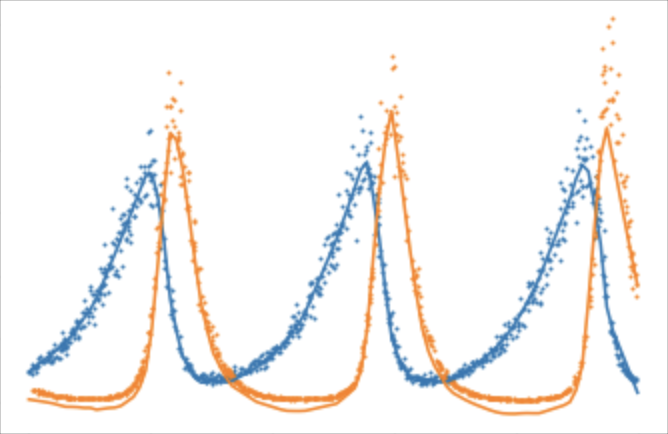

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import pandas as pd

In [ ]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(1, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 2)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [ ]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(1, 64)
        self.fc2 = nn.Linear(64, 128)
        self.fc3 = nn.Linear(128, 256)
        self.fc4 = nn.Linear(256, 128)
        self.fc5 = nn.Linear(128, 64)
        self.fc6 = nn.Linear(64, 2)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.relu(self.fc4(x))
        x = self.relu(self.fc5(x))
        x = self.fc6(x)
        return x

In [ ]:
class TimeSeriesDataset(torch.utils.data.Dataset):

    def __init__(self, csv_file):
        data = pd.read_csv(csv_file, na_values="-") #.dropna()
        data = data.bfill().ffill()

        self.times = torch.tensor(data.iloc[:, 0].values, dtype=torch.float32).unsqueeze(1)
        self.values = torch.tensor(data.iloc[:, 1:3].values, dtype=torch.float32)

    def __len__(self):
        return len(self.times)

    def __getitem__(self, idx):
        return self.times[idx], self.values[idx]

In [ ]:
dataset = TimeSeriesDataset('data.csv')
BATCH_SIZE = 32
trainloader = torch.utils.data.DataLoader(
                  dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

def loss_fn(outputs, labels):
  mse_loss = nn.MSELoss()
  return mse_loss(outputs, labels)
    # return F.mse_loss(outputs, labels)

net = Net()
optimizer = optim.Adam(net.parameters(), lr=0.001) #TODO what is a good optimizer?



In [ ]:
for epoch in range(300):

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % 20 == 0:    # print every 20 mini-batches
            print('[%d, %5d] loss: %.3f' %
                  (epoch + 1, i + 1, running_loss / 20))
            running_loss = 0.0

print('Finished Training')

[1,     1] loss: 1.127
[1,    21] loss: 10.030
[1,    41] loss: 7.902
[1,    61] loss: 7.319
[2,     1] loss: 0.317
[2,    21] loss: 6.922
[2,    41] loss: 6.896
[2,    61] loss: 7.464
[3,     1] loss: 0.237
[3,    21] loss: 7.092
[3,    41] loss: 6.713
[3,    61] loss: 6.424
[4,     1] loss: 0.424
[4,    21] loss: 6.663
[4,    41] loss: 6.410
[4,    61] loss: 6.582
[5,     1] loss: 0.268
[5,    21] loss: 6.893
[5,    41] loss: 6.336
[5,    61] loss: 6.056
[6,     1] loss: 0.374
[6,    21] loss: 6.607
[6,    41] loss: 6.116
[6,    61] loss: 6.174
[7,     1] loss: 0.296
[7,    21] loss: 6.147
[7,    41] loss: 6.012
[7,    61] loss: 6.459
[8,     1] loss: 0.251
[8,    21] loss: 5.943
[8,    41] loss: 6.169
[8,    61] loss: 6.242
[9,     1] loss: 0.317
[9,    21] loss: 5.828
[9,    41] loss: 6.597
[9,    61] loss: 5.654
[10,     1] loss: 0.314
[10,    21] loss: 5.806
[10,    41] loss: 5.812
[10,    61] loss: 6.522
[11,     1] loss: 0.393
[11,    21] loss: 5.835
[11,    41] loss: 5.921
[11

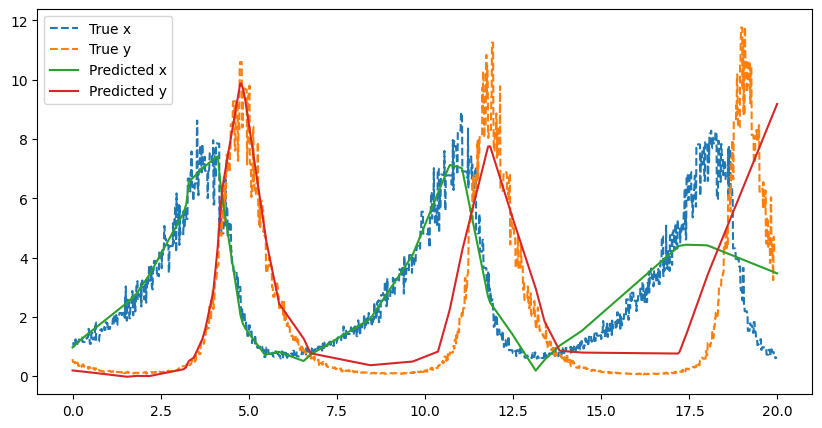

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

X_train = dataset[:][0]
Y_train = dataset[:][1]
Y_pred = net(X_train).detach().numpy()

plt.figure(figsize=(10, 5))
plt.plot(X_train.numpy(), Y_train.numpy()[:, 0], '--', label='True x')
plt.plot(X_train.numpy(), Y_train.numpy()[:, 1], '--', label='True y')
plt.plot(X_train.numpy(), Y_pred[:, 0], '-', label='Predicted x')
plt.plot(X_train.numpy(), Y_pred[:, 1], '-', label='Predicted y')
plt.legend()
plt.show()

# Part 2-2 Time-series extension

The simplified model above will only work well if $t\in[0,20]$.
Create a different model that can extrapolate `x,y` predictions to $t>20$.
Assume that the model has access to the same data as above, and is tasked to predict up to $t=100$. You can change anything in the above setup as needed, including model architecture, loss function, training procedure or data loader.

There are several different correct approaches to tackle this problem, all with different pros and cons, so make sure to explain your reasoning for the different choices made.


## Output for the extended dataset

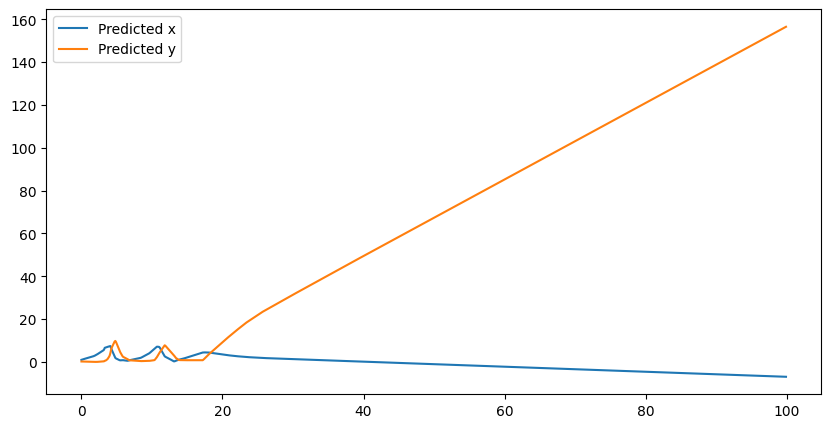

In [ ]:
# Generate x values until 100
X_vals = torch.arange(0, 100, 0.1).unsqueeze(1)

Y_pred = net(X_vals).detach().numpy()

plt.figure(figsize=(10, 5))
plt.plot(X_vals.numpy(), Y_pred[:, 0], '-', label='Predicted x')
plt.plot(X_vals.numpy(), Y_pred[:, 1], '-', label='Predicted y')
plt.legend()
plt.show()

## Different solution using MLP

In [ ]:
class NetHistory(nn.Module):
    def __init__(self, input_size=12, num_layers=10, hidden_size=512, output_size=2):
        super(NetHistory, self).__init__()

        self.model = nn.ModuleList()

        self.model.append(
            nn.Linear(input_size, hidden_size)
        )
        for i in range(num_layers):
          self.model.append(
              nn.Sequential(
                  nn.Linear(hidden_size, hidden_size),
                  nn.ReLU()
              )
          )

        self.model.append(nn.Linear(hidden_size, output_size))
        self.model.append(nn.ReLU())

    def forward(self, x):
        for layer in self.model:
          x = layer(x)
        return x

In [ ]:
from copy import deepcopy

class TimeSeriesDatasetWithHistory(torch.utils.data.Dataset):

    def __init__(self, csv_file):
        data = pd.read_csv(csv_file, na_values="-")#.dropna()
        data = data.bfill().ffill()
        self.times = torch.tensor(data.iloc[:, 0].values, dtype=torch.float32).unsqueeze(1)
        self.values = torch.tensor(data.iloc[:, 1:3].values, dtype=torch.float32)

        self.window = 20 # set window size to 20
    def __len__(self):
        return len(self.times)

    def __getitem__(self, idx):
        idx = max(self.window, idx)
        start = idx - self.window
        feature = torch.zeros((self.window * 3))

        # generate the feature vector with historical data
        for i in range(0, self.window*3, 3):
          # For each point in window, add t, x, and y
          feature[i] = self.times[start - i]
          feature[i+1] = self.values[start - i, 0]
          feature[i+2] = self.values[start - i, 1]
        feature[-1] = 0
        feature[-2] = 0

        return feature, self.values[idx]

In [ ]:
history_dataset = TimeSeriesDatasetWithHistory('data.csv')
BATCH_SIZE = 32
history_trainloader = torch.utils.data.DataLoader(
                  history_dataset, batch_size=BATCH_SIZE, shuffle=True)

loss_fn = nn.MSELoss()
device = "cuda"
net_history = NetHistory(input_size=60, num_layers=5, hidden_size=256, output_size=2)
net_history = net.to("cuda")
optimizer = optim.Adam(net.parameters(), lr=1e-3)

In [ ]:
for epoch in range(50):

    running_loss = 0.0
    for i, data in enumerate(history_trainloader):
        inputs, labels = data
        inputs = inputs.to(device)
        labels = labels.to(device)
        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net_history(inputs)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % 20 == 0:    # print every 20 mini-batches
            print('[%d, %5d] loss: %.3f' %
                  (epoch + 1, i + 1, running_loss / (i+1)))
            # running_loss = 0.0

print('Finished Training')

[1,     1] loss: 0.163
[1,    21] loss: 0.446
[1,    41] loss: 0.325
[1,    61] loss: 0.285
[2,     1] loss: 0.224
[2,    21] loss: 0.187
[2,    41] loss: 0.175
[2,    61] loss: 0.177
[3,     1] loss: 0.283
[3,    21] loss: 0.189
[3,    41] loss: 0.188
[3,    61] loss: 0.185
[4,     1] loss: 0.189
[4,    21] loss: 0.193
[4,    41] loss: 0.177
[4,    61] loss: 0.176
[5,     1] loss: 0.177
[5,    21] loss: 0.200
[5,    41] loss: 0.217
[5,    61] loss: 0.217
[6,     1] loss: 0.297
[6,    21] loss: 0.304
[6,    41] loss: 0.264
[6,    61] loss: 0.240
[7,     1] loss: 0.131
[7,    21] loss: 0.138
[7,    41] loss: 0.158
[7,    61] loss: 0.163
[8,     1] loss: 0.145
[8,    21] loss: 0.147
[8,    41] loss: 0.152
[8,    61] loss: 0.165
[9,     1] loss: 0.145
[9,    21] loss: 0.178
[9,    41] loss: 0.175
[9,    61] loss: 0.171
[10,     1] loss: 0.204
[10,    21] loss: 0.197
[10,    41] loss: 0.186
[10,    61] loss: 0.177
[11,     1] loss: 0.191
[11,    21] loss: 0.169
[11,    41] loss: 0.160
[11,

In [ ]:
def get_predictions(data_file="data.csv", window=20):

  data = pd.read_csv("data.csv", na_values="-")
  data = data.bfill().ffill()

  feature = []

  for i in range(window):
    t, x, y = data.iloc[i]
    feature.extend([t, x, y])
  feature[-2] = 0
  feature[-1] = 0

  preds = []
  for i in range(3, 3000):
    if i < len(data):
      t, x, y = data.iloc[i]
    else:
      t = t + 0.01
      x = pred_x
      y = pred_y

    # Make prediction
    input_x = torch.Tensor(feature).to(device)
    output = net_history(input_x).cpu().detach().numpy()
    pred_x, pred_y = output[0], output[1]
    preds.append(output)

    feature = feature[3:]

    if i < len(data):
      feature[-1] = y
      feature[-2] = x
    else:
      feature[-1] = pred_y
      feature[-2] = pred_x

    # add new time step with zeroed values
    t = t + 0.01

    feature.append(t)
    feature.append(0)
    feature.append(0)

  return preds


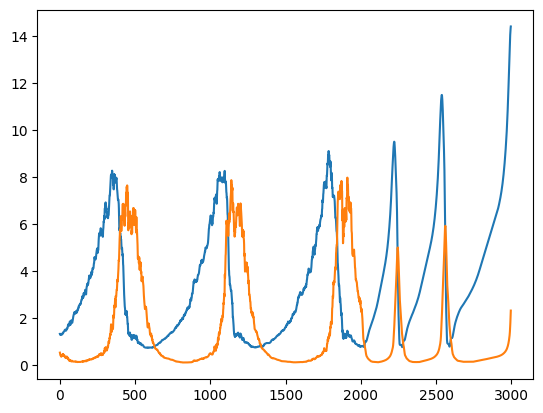

In [ ]:
preds = get_predictions("data.csv", 20)

plt.plot(np.array(preds))

# Part 3-1a

Please implement the below function `min_dist`. This function should take a sparse list of 2D coordinates, and map them to a 2D tensor of a specified resolution. The values of each pixel in the tensor should correspond to the [euclidean distance](https://en.wikipedia.org/wiki/Euclidean_distance) between that pixel and the closest pixel which contains a data point.

You can use either numpy or pytorch tensor operations to implement the function. Use only tensor operations, no for-loops are necessary.

Here are the example outputs for the two test cases highlighted below:

Case 1: data at `[0.4, 0.3], [0.6, 0.7]`, resolution 20 pixels.

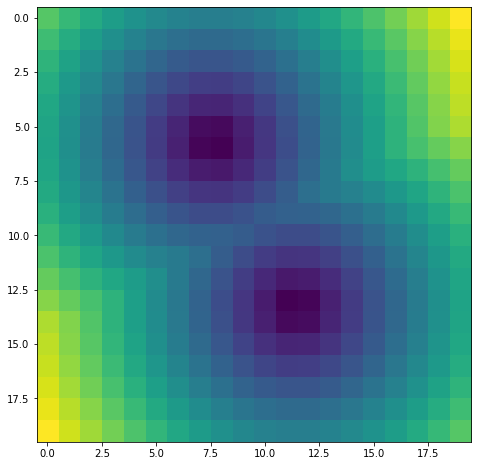


Case 2: data at `[0.4, 0.3], [0.6, 0.7], [0.3, 0.8], [0.5, 0.2]`, resolution 256 pixels.

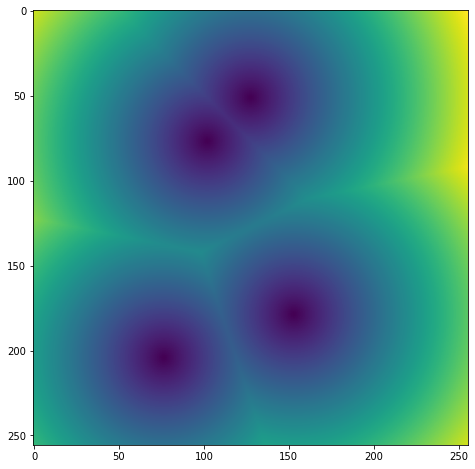


In [ ]:
import torch
import matplotlib.pyplot as plt

def min_dist(points, res):
    """Calculates a 2D tensor with the minimum distance from each pixel to data.

    Inputs:
      * points: a python list of 2D coordinates, normalized in the range [0,1]
      * res: the resolution of the output tensor.
    Returns:
      A res x res square tensor with floating point values corresponding to the
      euclidean distance to the closest point in points.
    """
    # Create a grid
    xs = torch.linspace(0, 1, res)
    ys = torch.linspace(0, 1, res)
    grid_x, grid_y = torch.meshgrid(xs, ys, indexing='xy')
    grid_points = torch.stack([grid_x.flatten(), grid_y.flatten()], dim=1)

    data_tensor = torch.tensor(points, dtype=torch.float32)

    # compute euclidean distance
    distances = torch.cdist(grid_points, data_tensor)

    # get minimum distance
    min_distances = torch.min(distances, dim=1).values

    # reshape
    distance_grid = min_distances.view(res, res)

    return distance_grid

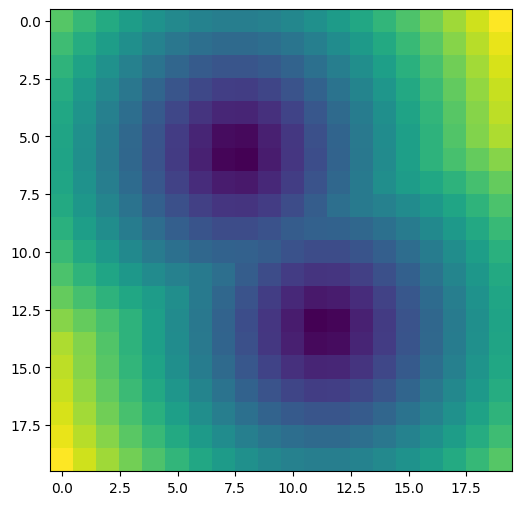

In [ ]:
# case 1
points = [[0.4, 0.3], [0.6, 0.7]]
res = 20

dist_grid = min_dist(points, res)

plt.figure(figsize=(6, 6))
plt.imshow(dist_grid, origin='upper')
plt.show()

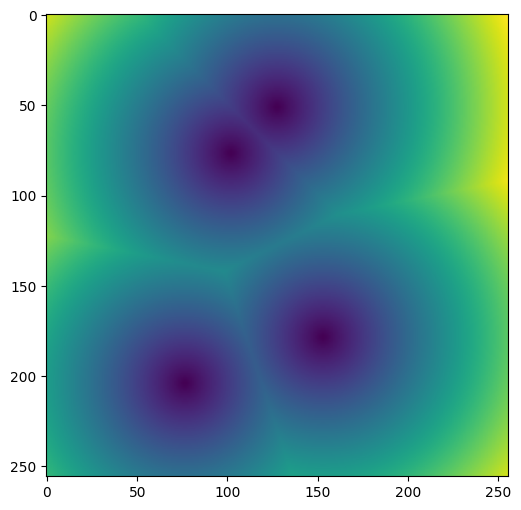

In [ ]:
# case 2
points2 = [[0.4, 0.3], [0.6, 0.7], [0.3, 0.8], [0.5, 0.2]]
res = 256

dist_data2 = min_dist(points2, res)
plt.figure(figsize=(6, 6))
plt.imshow(dist_data2)

# Part 3-1b: Batched version

As a next step, improve the `min_dist` function to support batches.
The `points` array is now expected to be a tensor with shape [batch_size, num_points, 3], generated by `create_points`.
`min_dist` should return a batch of maps with shape [batch_size, res, res].
Again, make sure to implement `min_dist` using **no for-loops**.
Demonstrate your function output with `batch_size=3` and `num_points=4`.

In [ ]:
def create_points(batch_size, num_points):
  coords = np.random.rand(batch_size, num_points, 2)
  return coords

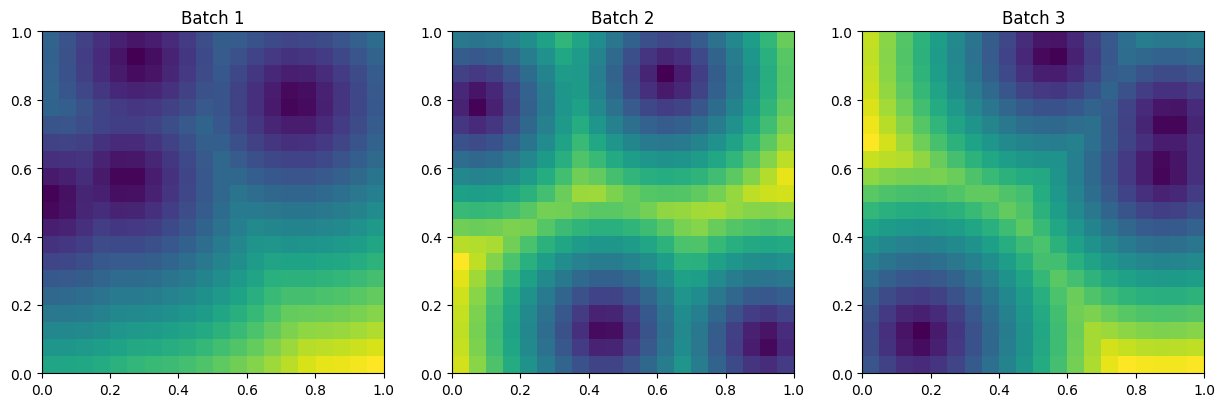

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def min_dist(points, res):
    """
    Computes a batch of distance maps, where each pixel stores the distance to the nearest data point.

    Args:
        points (torch.Tensor): A tensor of shape [B, P, 2] representing batch_size sets of 2D points.
        res (int): Resolution of the output distance maps.

    Returns:
        torch.Tensor: A tensor of shape [B, res, res] containing minimum distances.
    """
    B, P, _ = points.shape

    # create a 2D grid
    grid_x, grid_y = torch.meshgrid(torch.linspace(0, 1, res), torch.linspace(0, 1, res), indexing='xy')
    grid = torch.stack([grid_x, grid_y], dim=-1)

    # Expand grid to [B, res, res, 2] to match batch size
    grid = grid.unsqueeze(0).expand(B, -1, -1, -1)
    points = points[:, None, None, :, :]

    # Compute Euclidean distance
    distances = torch.cdist(grid.view(B, -1, 2), points.view(B, P, 2))
    min_distances = torch.min(distances, dim=2).values
    return min_distances.view(B, res, res)


batch_size = 3
num_points = 4
res = 20
points = create_points(batch_size, num_points)

# generte map
dist_maps = min_dist(torch.tensor(points, dtype=torch.float32), res)

# Visualization
fig, axes = plt.subplots(1, batch_size, figsize=(15, 5))
for i in range(batch_size):
    ax = axes[i]
    ax.imshow(dist_maps[i].numpy(), origin='upper', extent=[0, 1, 0, 1])
    ax.set_title(f"Batch {i+1}")
plt.show()


# Part 3-2: Scalable version

Assume `res` can be very large (up to 65,536). Running the above function will likely cause the computer's RAM to be filled up, and fail (on a free colab instance, even 16,384 `res` will crash with `batch_size=3` and `num_points=4`).
Extend the above version of `min_dist` to calculate the result tensor at such high resolution without running out of RAM. This function may be less computationally efficient, as long as it can successfully run.

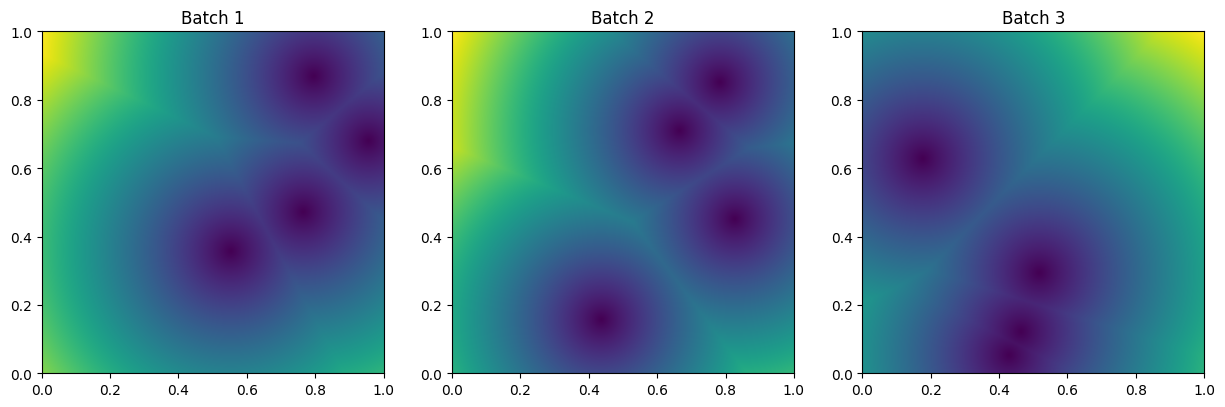

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def min_dist(points, res, chunk_size=512):
    """
    Computes a batch of distance maps, optimized for high resolution by processing in chunks.

    Args:
        points (torch.Tensor): A tensor of shape [B, P, 2] representing batch_size sets of 2D points.
        res (int): Resolution of the output distance maps.
        chunk_size (int): Number of rows to process at once to reduce memory load.

    Returns:
        torch.Tensor: A tensor of shape [B, res, res] containing minimum distances.
    """
    B, P, _ = points.shape

    min_distances = torch.full((B, res, res), float('inf'), dtype=torch.float32)

    # Iterate chunks along the first dimension
    for i in range(0, res, chunk_size):
        end = min(i + chunk_size, res)

        # create grid for current chunk
        grid_x = torch.linspace(0, 1, res)
        grid_y = torch.linspace(i / res, end / res, end - i)
        grid_x, grid_y = torch.meshgrid(grid_x, grid_y, indexing='xy')
        grid = torch.stack([grid_x, grid_y], dim=-1).view(-1, 2)

        grid = grid.unsqueeze(0).expand(B, -1, -1)
        distances = torch.cdist(grid, points)

        # Find the minimum distance per pixel
        min_chunk_distances = torch.min(distances, dim=2).values
        min_distances[:, i:end, :] = min_chunk_distances.view(B, end - i, res)
    return min_distances

batch_size = 3
num_points = 4
res = 1024

points = create_points(batch_size, num_points)

# generate distance map
dist_maps = min_dist(torch.tensor(points, dtype=torch.float32), res, chunk_size=128)

# Visualization
fig, axes = plt.subplots(1, batch_size, figsize=(15, 5))
for i in range(batch_size):
    ax = axes[i]
    ax.imshow(dist_maps[i].cpu().numpy(), origin='lower', extent=[0, 1, 0, 1])
    ax.set_title(f"Batch {i+1}")
plt.show()
